In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

BASE_DIR = Path("..")

nav = pd.read_csv(
    BASE_DIR / "data/processed/02_nav_history_clean.csv"
)

fund_master = pd.read_csv(
    BASE_DIR / "data/processed/01_fund_master.csv"
)

nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
    ["amfi_code", "date"]
).reset_index(drop=True)

print("NAV shape:", nav.shape)
print("Number of funds:", nav["amfi_code"].nunique())
print(nav.head())

NAV shape: (46000, 3)
Number of funds: 40
   amfi_code       date       nav
0     100016 2022-01-03  520.4608
1     100016 2022-01-04  515.0971
2     100016 2022-01-05  521.7239
3     100016 2022-01-06  515.7880
4     100016 2022-01-07  515.1639


In [2]:
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

print("Daily return calculation complete.")
print(nav["daily_return"].describe())

Daily return calculation complete.
count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64


In [3]:
results = []

for amfi_code, fund_data in nav.groupby("amfi_code"):

    returns = fund_data["daily_return"].dropna()

    # Historical VaR at 95% confidence
    var_95 = np.percentile(returns, 5)

    # CVaR = average of returns worse than VaR
    cvar_95 = returns[returns <= var_95].mean()

    results.append({
        "amfi_code": amfi_code,
        "VaR_95_pct": var_95 * 100,
        "CVaR_95_pct": cvar_95 * 100,
        "observations": len(returns)
    })

var_cvar_report = pd.DataFrame(results)

In [4]:
var_cvar_report = var_cvar_report.merge(
    fund_master[
        [
            "amfi_code",
            "scheme_name",
            "fund_house",
            "category",
            "risk_category"
        ]
    ],
    on="amfi_code",
    how="left"
)

var_cvar_report = var_cvar_report[
    [
        "amfi_code",
        "scheme_name",
        "fund_house",
        "category",
        "risk_category",
        "observations",
        "VaR_95_pct",
        "CVaR_95_pct"
    ]
]

var_cvar_report["VaR_95_pct"] = (
    var_cvar_report["VaR_95_pct"].round(2)
)

var_cvar_report["CVaR_95_pct"] = (
    var_cvar_report["CVaR_95_pct"].round(2)
)

var_cvar_report = var_cvar_report.sort_values(
    "VaR_95_pct"
)

In [5]:
print("TOP 10 FUNDS — HIGHEST HISTORICAL VaR")

display(
    var_cvar_report[
        [
            "scheme_name",
            "risk_category",
            "VaR_95_pct",
            "CVaR_95_pct"
        ]
    ].head(10)
)

TOP 10 FUNDS — HIGHEST HISTORICAL VaR


,scheme_name,risk_category,VaR_95_pct,CVaR_95_pct
22,SBI Small Cap Fund - Direct Plan - Growth,Very High,-2.69,-3.24
17,Axis Small Cap Fund - Regular - Growth,Very High,-2.62,-3.17
4,ABSL Small Cap Fund - Regular - Growth,Very High,-2.60,-3.25
11,Nippon India Small Cap Fund - Regular - Growth,Very High,-2.54,-3.23
21,SBI Small Cap Fund - Regular Plan - Growth,Very High,-2.45,-3.06
39,DSP Small Cap Fund - Regular - Growth,Very High,-2.35,-3.10
7,UTI Mid Cap Fund - Regular - Growth,High,-1.92,-2.33
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,High,-1.90,-2.35
25,ICICI Pru Midcap Fund - Regular - Growth,High,-1.89,-2.43
16,Axis Midcap Fund - Regular - Growth,High,-1.85,-2.43


In [6]:
output_path = BASE_DIR / "data/processed/var_cvar_report.csv"

var_cvar_report.to_csv(
    output_path,
    index=False
)

print("Saved to:", output_path)
print("Total funds:", len(var_cvar_report))
print(
    "Missing VaR:",
    var_cvar_report["VaR_95_pct"].isna().sum()
)
print(
    "Missing CVaR:",
    var_cvar_report["CVaR_95_pct"].isna().sum()
)

Saved to: ..\data\processed\var_cvar_report.csv
Total funds: 40
Missing VaR: 0
Missing CVaR: 0


In [7]:
# TASK 2: ROLLING 90-DAY SHARPE RATIO

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

nav = pd.read_csv(
    BASE_DIR / "data/processed/02_nav_history_clean.csv"
)

fund_master = pd.read_csv(
    BASE_DIR / "data/processed/01_fund_master.csv"
)

fund_scorecard = pd.read_csv(
    BASE_DIR / "data/processed/fund_scorecard.csv"
)

nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
    ["amfi_code", "date"]
).reset_index(drop=True)

# Select top 5 funds from Day 4 scorecard
top5 = (
    fund_scorecard
    .sort_values("Overall_Rank")
    .head(5)
)

print("Selected funds:")
display(
    top5[
        ["Overall_Rank", "scheme_name", "Overall_Score"]
    ]
)

Selected funds:


,Overall_Rank,scheme_name,Overall_Score
0,1,SBI Small Cap Fund - Regular Plan - Growth,78.10
1,2,DSP Small Cap Fund - Regular - Growth,74.90
2,3,Mirae Asset Large Cap Fund - Regular - Growth,73.33
3,4,SBI Bluechip Fund - Regular Plan - Growth,73.15
4,5,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,72.96


In [8]:
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

selected_codes = top5["amfi_code"].tolist()

nav_selected = nav[
    nav["amfi_code"].isin(selected_codes)
].copy()

In [10]:
nav_selected["rolling_mean_90"] = (
    nav_selected
    .groupby("amfi_code")["daily_return"]
    .transform(
        lambda x: x.rolling(90).mean()
    )
)

nav_selected["rolling_std_90"] = (
    nav_selected
    .groupby("amfi_code")["daily_return"]
    .transform(
        lambda x: x.rolling(90).std()
    )
)

nav_selected["rolling_sharpe_90"] = (
    nav_selected["rolling_mean_90"]
    / nav_selected["rolling_std_90"]
    * np.sqrt(252)
)

In [11]:
nav_selected = nav_selected.merge(
    fund_master[
        [
            "amfi_code",
            "scheme_name"
        ]
    ],
    on="amfi_code",
    how="left"
)

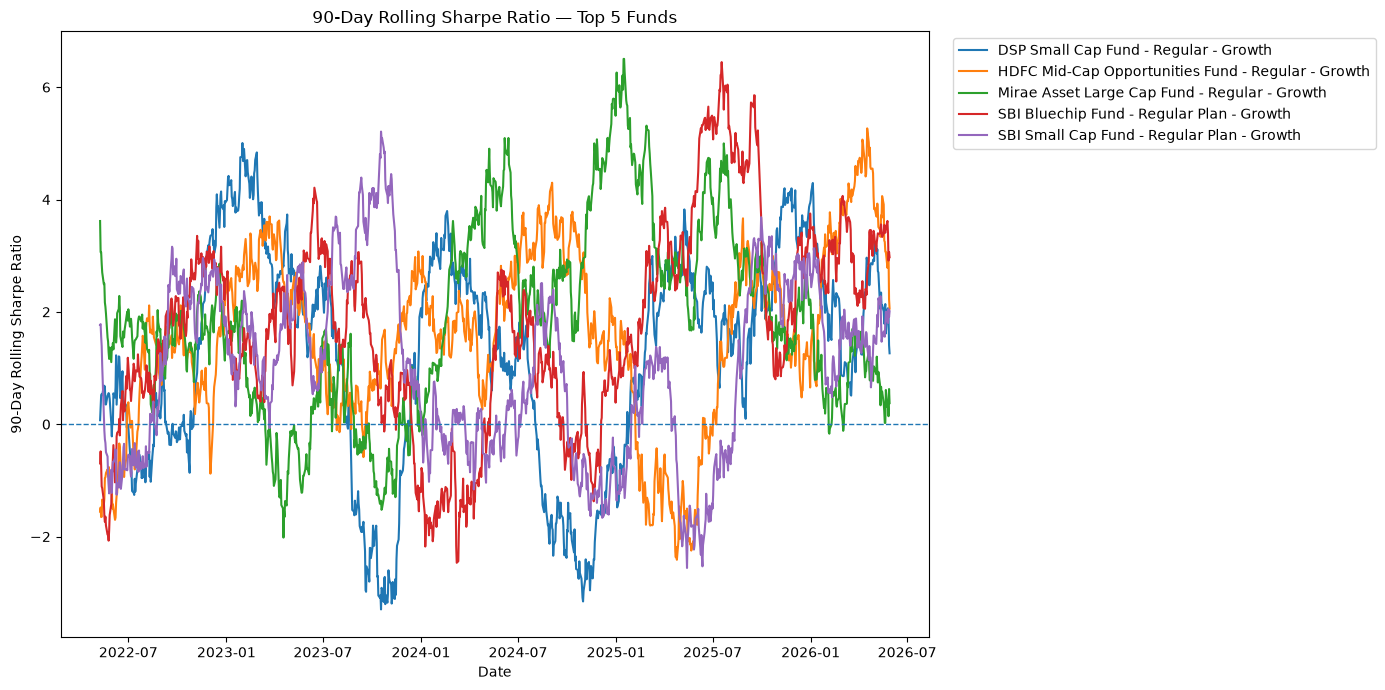

In [12]:
plt.figure(figsize=(14, 7))

for fund_name, fund_data in nav_selected.groupby("scheme_name"):
    
    fund_data = fund_data.sort_values("date")
    
    plt.plot(
        fund_data["date"],
        fund_data["rolling_sharpe_90"],
        label=fund_name
    )

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Date")
plt.ylabel("90-Day Rolling Sharpe Ratio")
plt.title("90-Day Rolling Sharpe Ratio — Top 5 Funds")

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

In [13]:
chart_path = (
    BASE_DIR /
    "data/processed/rolling_sharpe_chart.png"
)

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart saved to:", chart_path)

<Figure size 640x480 with 0 Axes>

Chart saved to: ..\data\processed\rolling_sharpe_chart.png


In [14]:
print("Rolling Sharpe calculation complete.")

display(
    nav_selected[
        [
            "date",
            "scheme_name",
            "rolling_sharpe_90"
        ]
    ]
    .dropna()
    .tail(10)
)

Rolling Sharpe calculation complete.


,date,scheme_name,rolling_sharpe_90
5740,2026-05-18,DSP Small Cap Fund - Regular - Growth,2.008546
5741,2026-05-19,DSP Small Cap Fund - Regular - Growth,1.790543
5742,2026-05-20,DSP Small Cap Fund - Regular - Growth,2.064489
5743,2026-05-21,DSP Small Cap Fund - Regular - Growth,2.138907
5744,2026-05-22,DSP Small Cap Fund - Regular - Growth,1.615362
5745,2026-05-25,DSP Small Cap Fund - Regular - Growth,2.042795
5746,2026-05-26,DSP Small Cap Fund - Regular - Growth,2.064950
5747,2026-05-27,DSP Small Cap Fund - Regular - Growth,1.952646
5748,2026-05-28,DSP Small Cap Fund - Regular - Growth,1.406239
5749,2026-05-29,DSP Small Cap Fund - Regular - Growth,1.262776


In [15]:
print(
    "Funds analyzed:",
    nav_selected["amfi_code"].nunique()
)

print(
    "Missing rolling Sharpe:",
    nav_selected["rolling_sharpe_90"].isna().sum()
)

Funds analyzed: 5
Missing rolling Sharpe: 450


In [17]:
# TASK 3: INVESTOR COHORT ANALYSIS

import pandas as pd
import numpy as np

transactions = pd.read_csv(
    BASE_DIR / "data/processed/08_investor_transactions_clean.csv"
)

transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

print("Transactions:", len(transactions))
print("Unique investors:", transactions["investor_id"].nunique())
print(
    "Date range:",
    transactions["transaction_date"].min(),
    "to",
    transactions["transaction_date"].max()
)

Transactions: 32778
Unique investors: 5000
Date range: 2024-01-01 00:00:00 to 2025-05-30 00:00:00


In [18]:
# Find first transaction date for each investor

first_transaction = (
    transactions
    .groupby("investor_id")["transaction_date"]
    .min()
    .reset_index()
)

first_transaction["cohort_year"] = (
    first_transaction["transaction_date"]
    .dt.year
)

display(first_transaction.head())

,investor_id,transaction_date,cohort_year
0,INV000001,2024-11-04,2024
1,INV000002,2024-03-29,2024
2,INV000003,2024-07-16,2024
3,INV000004,2024-03-16,2024
4,INV000005,2024-04-27,2024


In [19]:
transactions = transactions.merge(
    first_transaction[
        ["investor_id", "cohort_year"]
    ],
    on="investor_id",
    how="left"
)

print(
    transactions["cohort_year"]
    .value_counts()
    .sort_index()
)

cohort_year
2024    32499
2025      279
Name: count, dtype: int64


In [20]:
# Separate investment and redemption transactions

investment_transactions = transactions[
    transactions["transaction_type"].isin(
        ["SIP", "Lumpsum"]
    )
].copy()

redemption_transactions = transactions[
    transactions["transaction_type"] == "Redemption"
].copy()


# Investor count by cohort

investor_counts = (
    first_transaction
    .groupby("cohort_year")["investor_id"]
    .nunique()
    .reset_index(name="investor_count")
)


# Total invested by cohort

total_invested = (
    investment_transactions
    .groupby("cohort_year")["amount_inr"]
    .sum()
    .reset_index(name="total_invested_inr")
)


# Total redemption by cohort

total_redemption = (
    redemption_transactions
    .groupby("cohort_year")["amount_inr"]
    .sum()
    .reset_index(name="total_redemption_inr")
)


# Average SIP transaction amount

avg_sip = (
    transactions[
        transactions["transaction_type"] == "SIP"
    ]
    .groupby("cohort_year")["amount_inr"]
    .mean()
    .reset_index(name="average_sip_amount_inr")
)


# SIP amount by cohort

sip_amount = (
    transactions[
        transactions["transaction_type"] == "SIP"
    ]
    .groupby("cohort_year")["amount_inr"]
    .sum()
    .reset_index(name="sip_amount_inr")
)


# Lumpsum amount by cohort

lumpsum_amount = (
    transactions[
        transactions["transaction_type"] == "Lumpsum"
    ]
    .groupby("cohort_year")["amount_inr"]
    .sum()
    .reset_index(name="lumpsum_amount_inr")
)

In [21]:
cohort_analysis = investor_counts.merge(
    total_invested,
    on="cohort_year",
    how="left"
)

cohort_analysis = cohort_analysis.merge(
    total_redemption,
    on="cohort_year",
    how="left"
)

cohort_analysis = cohort_analysis.merge(
    avg_sip,
    on="cohort_year",
    how="left"
)

cohort_analysis = cohort_analysis.merge(
    sip_amount,
    on="cohort_year",
    how="left"
)

cohort_analysis = cohort_analysis.merge(
    lumpsum_amount,
    on="cohort_year",
    how="left"
)

cohort_analysis["total_redemption_inr"] = (
    cohort_analysis["total_redemption_inr"]
    .fillna(0)
)

cohort_analysis["net_invested_inr"] = (
    cohort_analysis["total_invested_inr"]
    - cohort_analysis["total_redemption_inr"]
)

In [22]:
cohort_analysis["investment_preference"] = np.where(
    cohort_analysis["sip_amount_inr"]
    >= cohort_analysis["lumpsum_amount_inr"],
    "SIP",
    "Lumpsum"
)

In [23]:
cohort_analysis["sip_amount_share_pct"] = (
    cohort_analysis["sip_amount_inr"]
    /
    (
        cohort_analysis["sip_amount_inr"]
        + cohort_analysis["lumpsum_amount_inr"]
    )
    * 100
)

In [24]:
cohort_analysis["total_invested_inr"] = (
    cohort_analysis["total_invested_inr"].round(2)
)

cohort_analysis["total_redemption_inr"] = (
    cohort_analysis["total_redemption_inr"].round(2)
)

cohort_analysis["net_invested_inr"] = (
    cohort_analysis["net_invested_inr"].round(2)
)

cohort_analysis["average_sip_amount_inr"] = (
    cohort_analysis["average_sip_amount_inr"].round(2)
)

cohort_analysis["sip_amount_inr"] = (
    cohort_analysis["sip_amount_inr"].round(2)
)

cohort_analysis["lumpsum_amount_inr"] = (
    cohort_analysis["lumpsum_amount_inr"].round(2)
)

cohort_analysis["sip_amount_share_pct"] = (
    cohort_analysis["sip_amount_share_pct"].round(2)
)

In [25]:
print("INVESTOR COHORT ANALYSIS")

display(cohort_analysis)

INVESTOR COHORT ANALYSIS


,cohort_year,investor_count,total_invested_inr,total_redemption_inr,average_sip_amount_inr,sip_amount_inr,lumpsum_amount_inr,net_invested_inr,investment_preference,sip_amount_share_pct
0,2024,4803,2258062304,1233062883,10996.89,214978121,2043084183,1024999421,Lumpsum,9.52
1,2025,197,18992635,11462608,13505.21,2255370,16737265,7530027,Lumpsum,11.87


In [26]:
cohort_path = (
    BASE_DIR /
    "data/processed/cohort_analysis.csv"
)

cohort_analysis.to_csv(
    cohort_path,
    index=False
)

print("Saved to:", cohort_path)
print("Cohorts:", len(cohort_analysis))
print(
    "Missing values:",
    cohort_analysis.isna().sum().sum()
)

Saved to: ..\data\processed\cohort_analysis.csv
Cohorts: 2
Missing values: 0


In [27]:
# TASK 4: SIP CONTINUITY / GAP ANALYSIS

sip = transactions[
    transactions["transaction_type"] == "SIP"
].copy()

sip = sip.sort_values(
    ["investor_id", "transaction_date"]
).reset_index(drop=True)

print("Total SIP transactions:", len(sip))
print("Unique SIP investors:", sip["investor_id"].nunique())

Total SIP transactions: 19716
Unique SIP investors: 4762


In [28]:
sip["previous_sip_date"] = (
    sip.groupby("investor_id")["transaction_date"]
    .shift(1)
)

sip["sip_gap_days"] = (
    sip["transaction_date"]
    - sip["previous_sip_date"]
).dt.days

In [29]:
sip["continuity_status"] = np.where(
    sip["sip_gap_days"] > 35,
    "At Risk",
    "Continuous"
)

In [30]:
continuity_summary = (
    sip.groupby("investor_id")
    .agg(
        first_sip_date=("transaction_date", "min"),
        last_sip_date=("transaction_date", "max"),
        total_sip_transactions=("transaction_date", "count"),
        total_sip_amount_inr=("amount_inr", "sum"),
        max_sip_gap_days=("sip_gap_days", "max"),
        average_sip_gap_days=("sip_gap_days", "mean")
    )
    .reset_index()
)

In [31]:
continuity_summary["continuity_status"] = np.where(
    continuity_summary["max_sip_gap_days"] > 35,
    "At Risk",
    "Continuous"
)

In [32]:
investor_info = (
    transactions
    .sort_values("transaction_date")
    .groupby("investor_id")
    .first()
    .reset_index()
)

investor_info = investor_info[
    [
        "investor_id",
        "state",
        "city",
        "city_tier",
        "age_group",
        "gender",
        "annual_income_lakh",
        "kyc_status"
    ]
]

In [33]:
sip_continuity = continuity_summary.merge(
    investor_info,
    on="investor_id",
    how="left"
)

In [34]:
sip_continuity["max_sip_gap_days"] = (
    sip_continuity["max_sip_gap_days"]
    .fillna(0)
)

sip_continuity["average_sip_gap_days"] = (
    sip_continuity["average_sip_gap_days"]
    .fillna(0)
    .round(2)
)

sip_continuity["total_sip_amount_inr"] = (
    sip_continuity["total_sip_amount_inr"]
    .round(2)
)

In [35]:
print("SIP CONTINUITY ANALYSIS")

print(
    "\nContinuity status:"
)

print(
    sip_continuity["continuity_status"]
    .value_counts()
)

print(
    "\nAt-risk investors:"
)

print(
    (sip_continuity["continuity_status"] == "At Risk")
    .sum()
)

print(
    "\nAt-risk percentage:"
)

print(
    round(
        (
            sip_continuity["continuity_status"] == "At Risk"
        ).mean() * 100,
        2
    ),
    "%"
)

display(
    sip_continuity
    .sort_values("max_sip_gap_days", ascending=False)
    .head(10)
)

SIP CONTINUITY ANALYSIS

Continuity status:
continuity_status
At Risk       3906
Continuous     856
Name: count, dtype: int64

At-risk investors:
3906

At-risk percentage:
82.02 %


,investor_id,first_sip_date,last_sip_date,total_sip_transactions,total_sip_amount_inr,max_sip_gap_days,average_sip_gap_days,continuity_status,state,city,city_tier,age_group,gender,annual_income_lakh,kyc_status
1775,INV001860,2024-01-03,2025-05-11,2,44713,494.0,494.0,At Risk,Karnataka,Mysore,B30,26-35,Female,9.0,Verified
2842,INV002986,2024-01-13,2025-05-12,2,4496,485.0,485.0,At Risk,Punjab,Amritsar,B30,26-35,Male,11.9,Verified
3154,INV003312,2024-01-10,2025-05-06,2,11876,482.0,482.0,At Risk,Maharashtra,Mumbai,T30,26-35,Male,7.9,Verified
2174,INV002278,2024-01-22,2025-05-10,2,3791,474.0,474.0,At Risk,Uttar Pradesh,Agra,B30,46-55,Female,88.6,Verified
2607,INV002740,2024-02-11,2025-05-30,2,5516,474.0,474.0,At Risk,Maharashtra,Mumbai,T30,26-35,Female,24.5,Verified
3683,INV003863,2024-01-10,2025-04-25,2,6928,471.0,471.0,At Risk,Gujarat,Surat,T30,36-45,Male,13.9,Verified
3950,INV004140,2024-01-18,2025-05-07,3,3723,470.0,237.5,At Risk,Punjab,Amritsar,B30,46-55,Female,41.6,Verified
3165,INV003324,2024-01-30,2025-05-13,2,18661,469.0,469.0,At Risk,Karnataka,Mysore,B30,26-35,Male,20.7,Verified
3323,INV003488,2024-02-06,2025-05-15,2,27153,464.0,464.0,At Risk,Gujarat,Surat,T30,46-55,Male,37.3,Verified
1535,INV001607,2024-02-10,2025-05-17,2,4350,462.0,462.0,At Risk,Punjab,Amritsar,B30,26-35,Male,14.8,Verified


In [36]:
sip_path = (
    BASE_DIR /
    "data/processed/sip_continuity.csv"
)

sip_continuity.to_csv(
    sip_path,
    index=False
)

print("\nSaved to:", sip_path)
print("Total SIP investors:", len(sip_continuity))
print(
    "Missing values:",
    sip_continuity.isna().sum().sum()
)


Saved to: ..\data\processed\sip_continuity.csv
Total SIP investors: 4762
Missing values: 0


# Day 6 — Advanced Analytics

## Mutual Fund Analytics Platform

This notebook summarizes the advanced analytics developed for the Bluestock Fintech Mutual Fund Analytics Platform.

### Analyses Covered

1. Historical Value at Risk (VaR) and Conditional VaR (CVaR)
2. Rolling 90-Day Sharpe Ratio
3. Investor Cohort Analysis
4. SIP Continuity and Gap Analysis
5. Rule-Based Fund Recommendation Model
6. Sector Concentration and Herfindahl-Hirschman Index (HHI)

### Analytical Purpose

These analyses extend the basic performance and investor analytics developed earlier in the project by providing additional insights into:

- downside risk
- risk-adjusted performance stability
- investor behavior
- SIP continuity
- fund suitability
- portfolio concentration

> **Important:** Investor transactions and portfolio holdings are synthetic/constructed project data. Risk-free rate and certain analytical assumptions are project assumptions and should be documented accordingly.


In [37]:
from pathlib import Path
import pandas as pd
import numpy as np

BASE_DIR = Path.cwd().parent

processed = BASE_DIR / "data" / "processed"

var_cvar = pd.read_csv(processed / "var_cvar_report.csv")
rolling_sharpe = processed / "rolling_sharpe_chart.png"
cohort = pd.read_csv(processed / "cohort_analysis.csv")
sip_continuity = pd.read_csv(processed / "sip_continuity.csv")
recommendations = pd.read_csv(processed / "fund_recommendations.csv")
sector_hhi = pd.read_csv(processed / "sector_hhi.csv")

print("VaR/CVaR:", var_cvar.shape)
print("Cohort analysis:", cohort.shape)
print("SIP continuity:", sip_continuity.shape)
print("Recommendations:", recommendations.shape)
print("Sector HHI:", sector_hhi.shape)

VaR/CVaR: (40, 8)
Cohort analysis: (2, 10)
SIP continuity: (4762, 15)
Recommendations: (5, 20)
Sector HHI: (14, 8)


## 1. Historical VaR & CVaR

Historical 95% VaR estimates the daily return threshold that is exceeded on approximately 5% of trading observations.

CVaR measures the average return among observations that fall beyond the VaR threshold and therefore provides an indication of the severity of losses in the tail.

More negative values indicate greater downside risk.

The calculations use historical daily NAV returns.

In [38]:
print("VaR / CVaR Summary")

display(
    var_cvar[
        [
            "scheme_name",
            "category",
            "VaR_95_pct",
            "CVaR_95_pct"
        ]
    ]
    .sort_values("CVaR_95_pct")
    .head(10)
)

VaR / CVaR Summary


,scheme_name,category,VaR_95_pct,CVaR_95_pct
2,ABSL Small Cap Fund - Regular - Growth,Equity,-2.60,-3.25
0,SBI Small Cap Fund - Direct Plan - Growth,Equity,-2.69,-3.24
3,Nippon India Small Cap Fund - Regular - Growth,Equity,-2.54,-3.23
1,Axis Small Cap Fund - Regular - Growth,Equity,-2.62,-3.17
5,DSP Small Cap Fund - Regular - Growth,Equity,-2.35,-3.10
4,SBI Small Cap Fund - Regular Plan - Growth,Equity,-2.45,-3.06
9,Axis Midcap Fund - Regular - Growth,Equity,-1.85,-2.43
8,ICICI Pru Midcap Fund - Regular - Growth,Equity,-1.89,-2.43
7,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,-1.90,-2.35
6,UTI Mid Cap Fund - Regular - Growth,Equity,-1.92,-2.33


## 2. Rolling 90-Day Sharpe Ratio

A rolling 90-day Sharpe ratio is used to examine how risk-adjusted performance changes over time.

Unlike a single full-period Sharpe ratio, the rolling measure helps identify periods when a fund's risk-adjusted performance improves or deteriorates.

The analysis covers the five highest-ranked funds from the Day 4 fund scorecard.

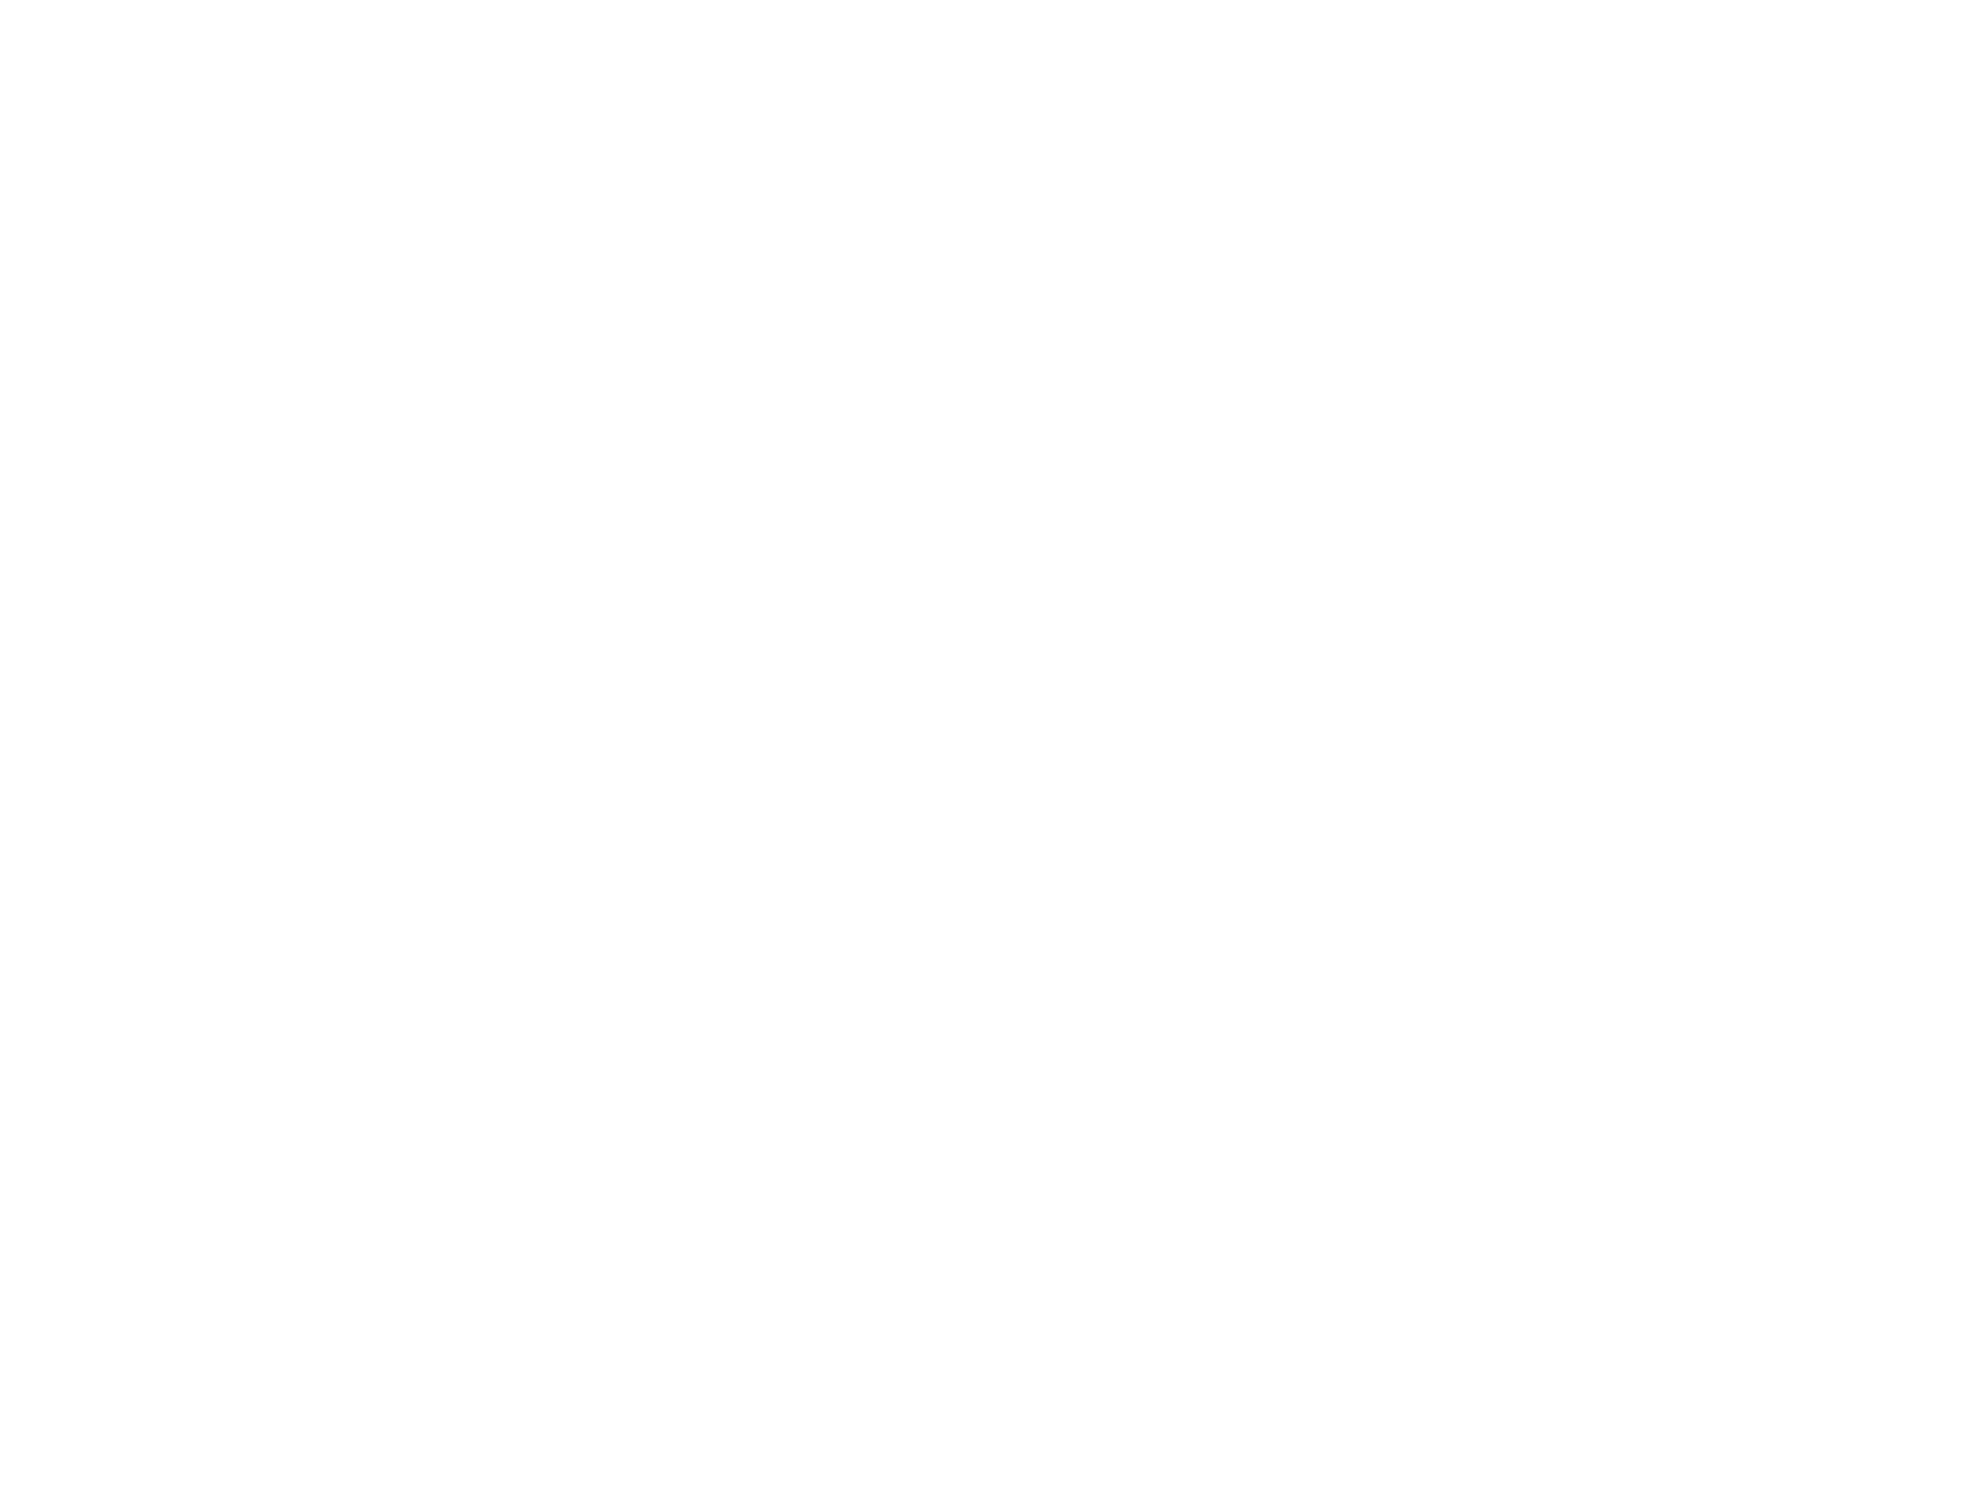

In [39]:
from IPython.display import Image, display

display(Image(
    filename=str(rolling_sharpe)
))

## 3. Investor Cohort Analysis

Investors are grouped according to the year of their first recorded transaction.

The analysis compares:

- investor count
- total investment
- redemptions
- net investment
- SIP preference
- average SIP amount

This helps identify differences in investor behavior across acquisition cohorts.

In [41]:
display(
    cohort.sort_values(
        "cohort_year"
    )
)

,cohort_year,investor_count,total_invested_inr,total_redemption_inr,average_sip_amount_inr,sip_amount_inr,lumpsum_amount_inr,net_invested_inr,investment_preference,sip_amount_share_pct
0,2024,4803,2258062304,1233062883,10996.89,214978121,2043084183,1024999421,Lumpsum,9.52
1,2025,197,18992635,11462608,13505.21,2255370,16737265,7530027,Lumpsum,11.87


In [42]:
print(
    "Largest investor cohort:",
    cohort.loc[
        cohort["investor_count"].idxmax(),
        "cohort_year"
    ]
)

print(
    "Total investors:",
    cohort["investor_count"].sum()
)

print(
    "Total net invested (₹):",
    round(
        cohort["net_invested_inr"].sum(),
        2
    )
)

Largest investor cohort: 2024
Total investors: 5000
Total net invested (₹): 1032529448


## 4. SIP Continuity & Gap Analysis

SIP continuity is evaluated using the gap between consecutive SIP transactions.

A gap greater than 35 days is classified as **At Risk**.

This threshold is a project-defined analytical rule rather than an industry-standard regulatory threshold.

The analysis helps identify investors whose SIP behavior may indicate reduced continuity.

In [43]:
status_counts = (
    sip_continuity["continuity_status"]
    .value_counts()
)

display(status_counts.to_frame("investor_count"))

,investor_count
continuity_status,
At Risk,3906
Continuous,856


In [44]:
at_risk_pct = (
    sip_continuity["continuity_status"]
    .eq("At Risk")
    .mean() * 100
)

print(
    f"At-risk SIP investors: "
    f"{(sip_continuity['continuity_status'] == 'At Risk').sum()}"
)

print(
    f"At-risk percentage: {at_risk_pct:.2f}%"
)

print(
    f"Continuous investors: "
    f"{(sip_continuity['continuity_status'] == 'Continuous').sum()}"
)

At-risk SIP investors: 3906
At-risk percentage: 82.02%
Continuous investors: 856


## 5. Rule-Based Fund Recommendation Model

A simple explainable recommendation model was developed to rank funds according to investor preferences.

The recommendation score combines:

- overall fund score
- risk compatibility
- investment-horizon suitability
- historical return

The model is intended as an analytical prototype and not as personalized financial advice.

In [45]:
display(
    recommendations[
        [
            "recommendation_rank",
            "scheme_name",
            "category",
            "risk_category",
            "CAGR_Till_Date_pct",
            "recommendation_score",
            "recommendation_reason"
        ]
    ]
)

,recommendation_rank,scheme_name,category,risk_category,CAGR_Till_Date_pct,recommendation_score,recommendation_reason
0,1,Mirae Asset Large Cap Fund - Regular - Growth,Equity,Moderate,30.97,93.130101,"Moderate risk profile, long-term suitability, ..."
1,2,SBI Bluechip Fund - Regular Plan - Growth,Equity,Moderate,25.80,89.762455,"Moderate risk profile, long-term suitability, ..."
2,3,Kotak Flexicap Fund - Regular - Growth,Equity,Moderately High,30.91,85.667057,"Moderately High risk profile, long-term suitab..."
3,4,ABSL Frontline Equity Fund - Regular - Growth,Equity,Moderate,23.54,84.329136,"Moderate risk profile, long-term suitability, ..."
4,5,Nippon India Large Cap Fund - Regular - Growth,Equity,Moderate,24.05,83.024191,"Moderate risk profile, long-term suitability, ..."


## 6. Sector Concentration & HHI

Sector concentration is measured using the Herfindahl-Hirschman Index (HHI).

The index is calculated using sector weights expressed as proportions.

A higher HHI indicates greater concentration, while a lower HHI indicates greater diversification.

The analysis also reports the combined concentration of the five largest sectors.

In [46]:
display(
    sector_hhi[
        [
            "sector",
            "weight_pct",
            "hhi_contribution"
        ]
    ]
)

,sector,weight_pct,hhi_contribution
0,Banking,652.26,42.544311
1,IT,455.47,20.745292
2,Pharma,407.45,16.601550
3,Automobile,323.65,10.474932
4,Utilities,265.54,7.051149
5,FMCG,229.11,5.249139
6,Infrastructure,192.16,3.692547
7,Diversified,169.23,2.863879
8,Telecom,145.62,2.120518
9,Consumer Goods,127.61,1.628431


In [47]:
hhi = sector_hhi["overall_hhi"].iloc[0]
hhi_10000 = sector_hhi["overall_hhi_10000"].iloc[0]
top5 = sector_hhi["top5_concentration_pct"].iloc[0]
effective = sector_hhi[
    "effective_number_of_sectors"
].iloc[0]

print(f"HHI (0-1): {hhi:.4f}")
print(f"HHI (0-10,000): {hhi_10000:.2f}")
print(f"Top 5 sector concentration: {top5:.2f}%")
print(f"Effective number of sectors: {effective:.2f}")

HHI (0-1): 117.6909
HHI (0-10,000): 1176908.81
Top 5 sector concentration: 2104.37%
Effective number of sectors: 0.01


# Advanced Analytics — Key Findings

### Risk
- Historical VaR and CVaR provide a fund-level view of downside tail risk.
- CVaR complements VaR by measuring the average severity of losses beyond the VaR threshold.

### Risk-Adjusted Performance
- Rolling 90-day Sharpe analysis shows how risk-adjusted performance changes through time.
- The analysis focuses on the five highest-ranked funds from the performance scorecard.

### Investor Behavior
- Cohort analysis reveals differences in investment and redemption behavior across investor acquisition years.
- SIP and lumpsum preferences can be compared across cohorts.

### SIP Continuity
- Investors with a SIP gap greater than 35 days are classified as At Risk.
- This provides a simple framework for identifying potentially discontinuous SIP behavior.

### Recommendations
- The rule-based recommender combines fund performance, risk compatibility and investment-horizon suitability.
- It provides an explainable ranking rather than a black-box prediction.

### Portfolio Concentration
- Sector HHI measures the concentration of holdings across sectors.
- The top-five sector concentration provides an additional intuitive diversification indicator.

### Data & Methodology Caveats
- Investor transactions are synthetic/constructed project data.
- Portfolio holdings and sector weights are synthetic/constructed project data.
- The SIP continuity threshold of 35 days is a project-defined rule.
- Historical NAV coverage is approximately 4.4 years, so a genuine five-year CAGR should not be claimed.
- Risk-adjusted metrics use the project's assumed 6% annual risk-free rate.